In [1]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [2]:
from sklearn.model_selection import train_test_split

# 훈련 세트와 테스트 세트로 나눕니다.
x_train, x_test, y_train, y_test = train_test_split(perch_length, perch_weight, random_state=42)

# 훈련 세트와 테스트 세트를 2차원 배열로 바꿈
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

x_train.shape, x_test.shape

((42, 1), (14, 1))

In [3]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

# k-최근접 이웃 회귀 모델을 훈련합니다.
knr.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [4]:
# 농어 길이가 50cm
knr.predict([[50]])

array([1033.33333333])

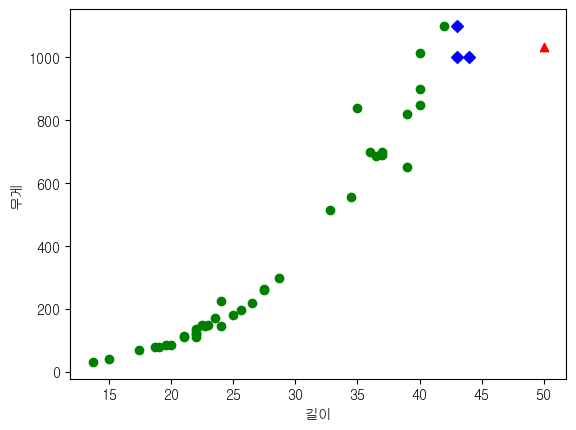

In [5]:
import matplotlib.pyplot as plt
plt.rc('font', family='Gulim')

# 50cm 농어의 이웃을 구합니다.
distance, indexes = knr.kneighbors([[50]])

# 훈련 세트의 산점도를 그립니다.
plt.scatter(x_train, y_train, c='g')

# 훈련 새트 중에서 이웃 샘플만 다시 그림
plt.scatter(x_train[indexes], y_train[indexes], marker='D', c='b')

# 50cm 농어 데이터
plt.scatter(50, 1033, marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [6]:
np.mean(y_train[indexes])

np.float64(1033.3333333333333)

In [7]:
# 100cm 농어도 동일한 결과가 나온다.
knr.predict([[100]])

array([1033.33333333])

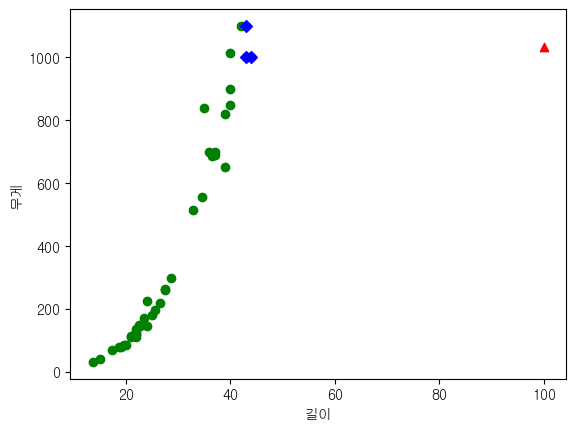

In [8]:
# 100cm 농어의 이웃을 구합니다.
distance, indexes = knr.kneighbors([[100]])
# 훈련 세트의 산점도 그리기
plt.scatter(x_train, y_train, c='g')
# 훈련 세트 중에서 이웃 샘플만 다시 그리기
plt.scatter(x_train[indexes], y_train[indexes], marker='D', c='b')
#100cm 농어 데이터
plt.scatter(100, 1033, marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# 선형 회귀 모델을 훈련합니다.
lr.fit(x_train, y_train)

# 50cm 농어 무게 예측
lr.predict([[50]])

array([1241.83860323])

In [10]:
lr.coef_, lr.intercept_

(array([39.01714496]), np.float64(-709.0186449535477))

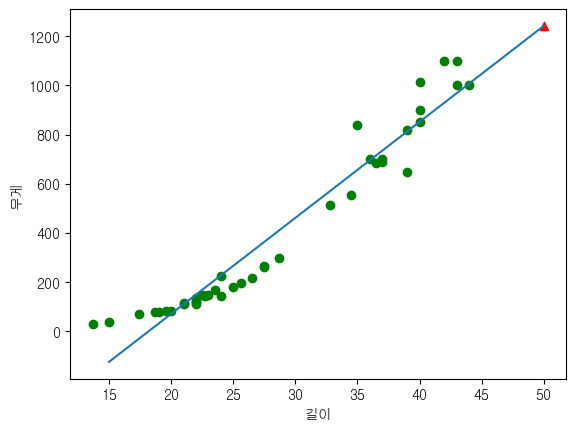

In [11]:
plt.scatter(x_train, y_train, c='g')
# 15에서 50까지 1차 방정식 그래프를 그립니다.
plt.plot([15,50], [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])
# 50cm 농어
plt.scatter(50, 1241.8, marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [23]:
# 훈련 세트, 테스트 세트
lr.score(x_train, y_train), lr.score(x_test, y_test)

ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

In [13]:
x_train_poly = np.column_stack((x_train ** 2, x_train))
x_test_poly = np.column_stack((x_test ** 2, x_test))

x_train_poly.shape, x_test_poly.shape

((42, 2), (14, 2))

In [20]:
lr = LinearRegression()
lr.fit(x_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# 50cm 농어 무게 예측
lr.predict([[50**2, 50]])

array([-53728.04563084])

In [22]:
lr.coef_, lr.intercept_

(array([-21.55792498,   1.01433211]), np.float64(116.05021078278315))

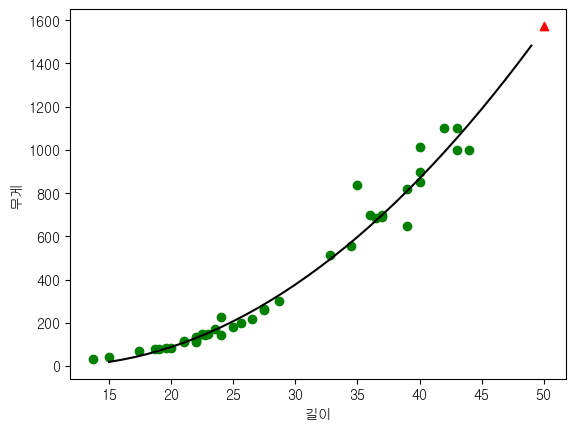

In [17]:
point = np.arange(15, 50)
plt.scatter(x_train, y_train, c='g')
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05, c='black')

plt.scatter(50, 1574, marker='^', c='r')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [18]:
lr.score(x_train_poly, y_train), lr.score(x_test_poly, y_test)

(0.9706807451768623, 0.9775935108325122)